# Differentiable SpaTiaL — Interactive Demo

This notebook demonstrates the core capabilities of **Differentiable SpaTiaL**:
1. Smooth signed distance computation between 3D convex polyhedra
2. Spatial predicates (closeTo, farFrom, leftOf, etc.)
3. Temporal operators (Always, Eventually)
4. End-to-end trajectory optimization via gradient descent

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

torch.set_default_dtype(torch.float64)
torch.manual_seed(42)

from diffspatiall.spatial import (
    make_box, make_cone, make_cylinder, compute_face_normals, extract_unique_edges,
    sat_penetration_depth_3d, point_signed_distance_to_polyhedron,
    polyhedron_signed_distance, batched_polyhedron_sd,
    batched_left_of, batched_above,
)
from diffspatiall.temporal import Always, Eventually
from diffspatiall.utils import smooth_min, smooth_max

print('All imports OK!')

All imports OK!


## 1. Create 3D Geometry

We create a cone obstacle and a box goal region.

Cone: 17 vertices, 30 faces
Goal: 8 vertices, 12 faces


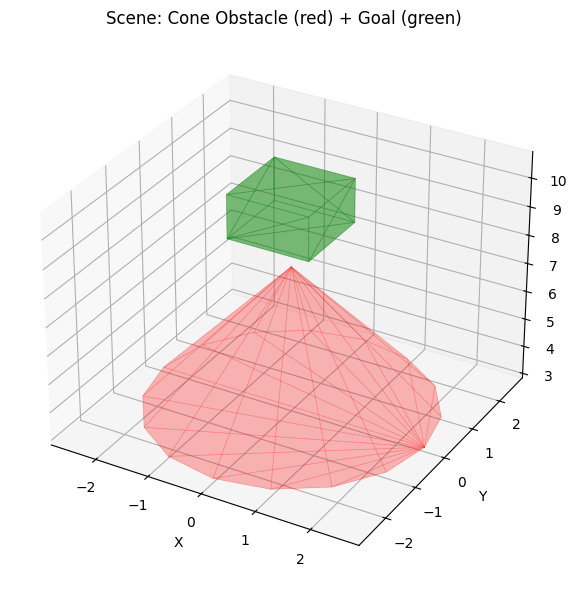

In [2]:
# Cone obstacle
cone_v, cone_f = make_cone(torch.tensor([0., 0., 3.]), radius=2.5, height=5.0, n_sides=16)
cone_n = compute_face_normals(cone_v, cone_f)
cone_e = extract_unique_edges(cone_f)
print(f'Cone: {cone_v.shape[0]} vertices, {cone_f.shape[0]} faces')

# Goal box
goal_v, goal_f = make_box(torch.tensor([-0.75, -0.75, 9.25]), torch.tensor([0.75, 0.75, 10.75]))
goal_n = compute_face_normals(goal_v, goal_f)
print(f'Goal: {goal_v.shape[0]} vertices, {goal_f.shape[0]} faces')

# Visualize
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

def draw_poly(ax, v, f, color, alpha=0.2):
    polys = [[v[fi].detach().numpy() for fi in face] for face in f]
    ax.add_collection3d(Poly3DCollection(polys, alpha=alpha, facecolor=color, edgecolor=color, lw=0.5))

draw_poly(ax, cone_v, cone_f, 'red', 0.15)
draw_poly(ax, goal_v, goal_f, 'green', 0.3)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Scene: Cone Obstacle (red) + Goal (green)')
plt.tight_layout()
plt.show()

## 2. Signed Distance Computation

Compute the differentiable signed distance between a robot (small box) and the cone obstacle as the robot moves.

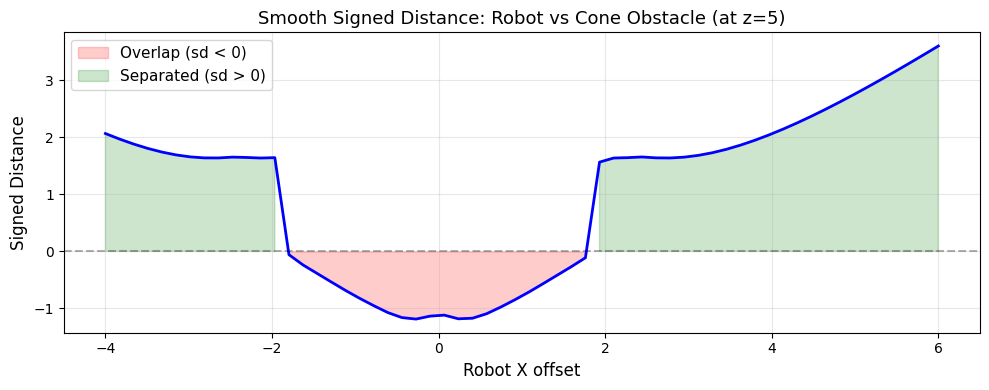

SD is smooth and differentiable everywhere!
Min SD = -1.1872 (deepest penetration)
Max SD = 3.6013 (farthest separation)


In [3]:
# Robot: small box
robot_v, robot_f = make_box(torch.tensor([-0.3, -0.3, -0.3]), torch.tensor([0.3, 0.3, 0.3]))

# Sweep robot along x-axis at z=5 (cone height), compute SD to cone
x_offsets = torch.linspace(-4, 6, 60)
sd_values = []

for x in x_offsets:
    rv = robot_v + torch.tensor([x.item(), 0., 5.])
    sd = point_signed_distance_to_polyhedron(rv, cone_v, cone_f, cone_n, tau=1e-2)
    sd_values.append(smooth_min(sd, dim=-1, tau=1e-2).item())

plt.figure(figsize=(10, 4))
plt.plot(x_offsets.numpy(), sd_values, 'b-', lw=2)
plt.axhline(y=0, color='k', ls='--', alpha=0.3)
plt.fill_between(x_offsets.numpy(), sd_values, 0,
                  where=[s < 0 for s in sd_values], alpha=0.2, color='red', label='Overlap (sd < 0)')
plt.fill_between(x_offsets.numpy(), sd_values, 0,
                  where=[s >= 0 for s in sd_values], alpha=0.2, color='green', label='Separated (sd > 0)')
plt.xlabel('Robot X offset', fontsize=12)
plt.ylabel('Signed Distance', fontsize=12)
plt.title('Smooth Signed Distance: Robot vs Cone Obstacle (at z=5)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'SD is smooth and differentiable everywhere!')
print(f'Min SD = {min(sd_values):.4f} (deepest penetration)')
print(f'Max SD = {max(sd_values):.4f} (farthest separation)')

## 3. Gradient Verification

The key advantage: gradients flow through the SD computation.

In [4]:
# Robot position as a learnable parameter
robot_pos = torch.tensor([0., 0., 5.], requires_grad=True)
rv = robot_v + robot_pos

# Compute SD and backpropagate
sd = point_signed_distance_to_polyhedron(rv, cone_v, cone_f, cone_n, tau=1e-2)
sd_min = smooth_min(sd, dim=-1, tau=1e-2)
sd_min.backward()

print(f'SD value: {sd_min.item():.4f}')
print(f'Gradient w.r.t. position: {robot_pos.grad.numpy()}')
print(f'\nThe gradient tells us: move in direction {robot_pos.grad.numpy()} to INCREASE the SD.')
print(f'This is the "push away" signal for collision avoidance!')

SD value: -1.0863
Gradient w.r.t. position: [5.73168818e-10 6.76175782e-12 4.40299503e-01]

The gradient tells us: move in direction [5.73168818e-10 6.76175782e-12 4.40299503e-01] to INCREASE the SD.
This is the "push away" signal for collision avoidance!


## 4. Spatial Predicates

Each predicate returns a robustness value: positive = satisfied, negative = violated.

In [5]:
# Two boxes
boxA = make_box(torch.tensor([-1., -0.5, -0.5]), torch.tensor([0., 0.5, 0.5]))[0]
boxB = make_box(torch.tensor([1.5, -0.5, -0.5]), torch.tensor([2.5, 0.5, 0.5]))[0]

# Directional predicates
print('=== Directional Predicates ===')
print(f'leftOf(A, B)  = {batched_left_of(boxA, boxB).item():+.3f}  (A is left of B? YES)')
print(f'leftOf(B, A)  = {batched_left_of(boxB, boxA).item():+.3f}  (B is left of A? NO)')
print(f'above(A, B)   = {batched_above(boxA, boxB).item():+.3f}  (A is above B? NO, same height)')

# Move A above B
boxA_high = boxA + torch.tensor([1.5, 0., 2.])
print(f'above(A\u2191, B)  = {batched_above(boxA_high, boxB).item():+.3f}  (A moved up -> YES)')

print(f'\nPositive = satisfied, Negative = violated')

=== Directional Predicates ===
leftOf(A, B)  = +1.472  (A is left of B? YES)
leftOf(B, A)  = -3.528  (B is left of A? NO)
above(A, B)   = -1.028  (A is above B? NO, same height)
above(A↑, B)  = +0.972  (A moved up -> YES)

Positive = satisfied, Negative = violated


## 5. Temporal Operators

Always and Eventually on robustness signals.

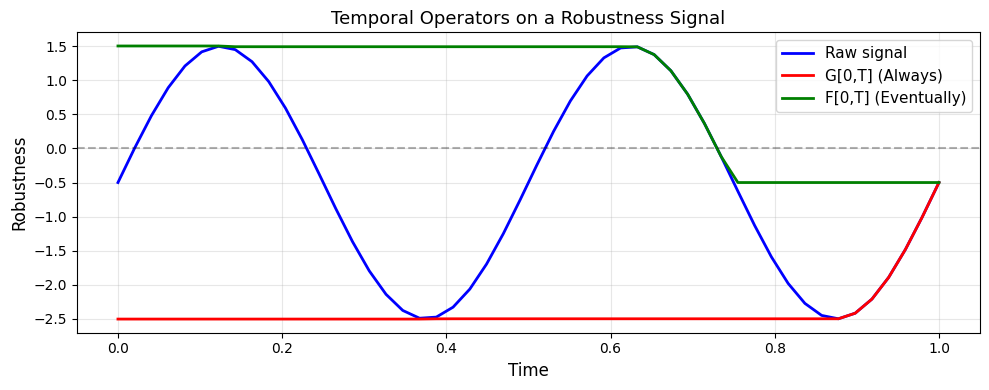

Always: worst-case robustness at each t (running min from t to T)
Eventually: best-case robustness at each t (running max from t to T)


In [6]:
# A robustness signal over time
T = 50
t = torch.linspace(0, 1, T)
signal = (torch.sin(4 * 3.14159 * t) * 2 - 0.5).unsqueeze(0).unsqueeze(-1)  # (1, T, 1)

# Apply temporal operators
always_result = Always()(signal, tau=1e-2)
eventually_result = Eventually()(signal, tau=1e-2)

plt.figure(figsize=(10, 4))
plt.plot(t.numpy(), signal[0, :, 0].numpy(), 'b-', lw=2, label='Raw signal')
plt.plot(t.numpy(), always_result[0, :, 0].detach().numpy(), 'r-', lw=2, label='G[0,T] (Always)')
plt.plot(t.numpy(), eventually_result[0, :, 0].detach().numpy(), 'g-', lw=2, label='F[0,T] (Eventually)')
plt.axhline(y=0, color='k', ls='--', alpha=0.3)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Robustness', fontsize=12)
plt.title('Temporal Operators on a Robustness Signal', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Always: worst-case robustness at each t (running min from t to T)')
print(f'Eventually: best-case robustness at each t (running max from t to T)')

## 6. Trajectory Optimization

Optimize a 3D trajectory to satisfy:

$$\phi = G(\text{farFrom}(\text{robot}, \text{cone}, 0.5)) \wedge F(\text{closeTo}(\text{robot}, \text{goal}, 0.5))$$

The robot must **always** stay far from the cone obstacle **and** **eventually** reach close to the goal.

In [7]:
T = 40
eps_far = 0.5
eps_close = 0.5

# Initialize trajectory: straight line from (0,0,0) to (0,0,10)
# This goes DIRECTLY THROUGH the cone (base z=3, tip z=8, radius 2.5)
start = torch.tensor([0., 0., 0.])
end_pt = torch.tensor([0., 0., 10.])
t_interp = torch.linspace(0, 1, T).unsqueeze(1)
traj = (start * (1 - t_interp) + end_pt * t_interp).clone()

# Small symmetry-breaking perturbation (trajectory still goes through the cone)
traj[6:-6, 0] += 1.0
traj = torch.nn.Parameter(traj)

optimizer = torch.optim.Adam([traj], lr=0.12)
robustness_history = []
phase2_start = None

for it in range(500):
    optimizer.zero_grad()

    # Fix start and end points
    centers = torch.cat([start.unsqueeze(0), traj[1:-1], end_pt.unsqueeze(0)], dim=0)
    robot_traj = centers.unsqueeze(1) + robot_v.unsqueeze(0)  # (T, V, 3)

    sd_cone = batched_polyhedron_sd(robot_traj, cone_v, cone_f, cone_n,
                                    tau=1e-2, robot_faces=robot_f)
    sd_goal = batched_polyhedron_sd(robot_traj, goal_v, goal_f, goal_n,
                                    tau=1e-2, robot_faces=robot_f)

    far_rob = sd_cone - eps_far
    close_rob = eps_close - torch.nn.functional.relu(sd_goal)

    # Phase 1: large tau to escape cone; Phase 2: small tau + smoothness to tighten path
    if phase2_start is None:
        t_tau, smooth_w = 0.5, 0.05
    else:
        t_tau, smooth_w = 0.05, 0.5

    always_far = Always()(far_rob.unsqueeze(0).unsqueeze(-1), tau=t_tau)
    event_close = Eventually()(close_rob.unsqueeze(0).unsqueeze(-1), tau=t_tau)
    rob = torch.min(always_far[0, 0, 0], event_close[0, 0, 0])

    # Smoothness: acceleration penalty + step-length uniformity
    vel = centers[1:] - centers[:-1]
    acc = vel[1:] - vel[:-1]
    smooth_loss = (acc ** 2).sum() + 5.0 * vel.norm(dim=-1).var()

    # Once SAT, clamp robustness so optimizer focuses on path tightness
    rob_obj = -torch.clamp(rob, max=0.05) if phase2_start else -rob
    loss = rob_obj + smooth_w * smooth_loss
    loss.backward()
    optimizer.step()

    robustness_history.append(rob.item())

    # Switch to phase 2 once spec is satisfied
    if phase2_start is None and rob.item() > 0.2:
        phase2_start = it

    if (it + 1) % 100 == 0:
        status = 'SAT' if rob.item() >= 0 else 'UNSAT'
        print(f'Iter {it+1:3d}: robustness = {rob.item():+.4f} [{status}]')

print(f'\nFinal robustness: {robustness_history[-1]:+.4f}')

Iter 100: robustness = -0.2331 [UNSAT]
Iter 200: robustness = +0.0714 [SAT]
Iter 300: robustness = +0.0657 [SAT]
Iter 400: robustness = +0.0950 [SAT]
Iter 500: robustness = +0.1428 [SAT]

Final robustness: +0.1428


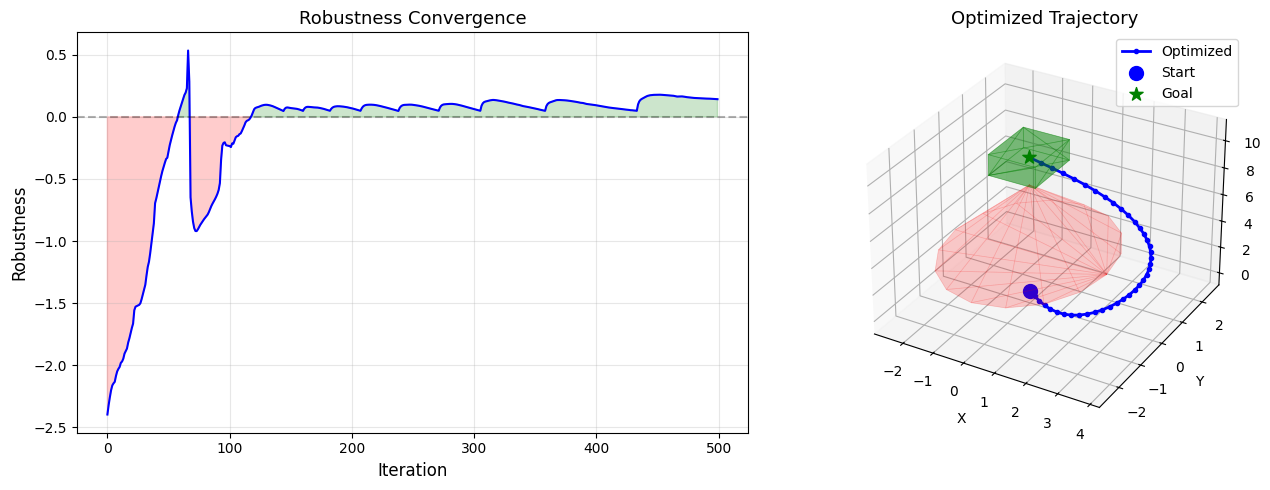

In [8]:
# Plot convergence and optimized trajectory
fig = plt.figure(figsize=(14, 5))

# Left: robustness over iterations
ax1 = fig.add_subplot(121)
ax1.plot(robustness_history, 'b-', lw=1.5)
ax1.axhline(y=0, color='k', ls='--', alpha=0.3)
ax1.fill_between(range(len(robustness_history)), robustness_history, 0,
                  where=[r >= 0 for r in robustness_history], alpha=0.2, color='green')
ax1.fill_between(range(len(robustness_history)), robustness_history, 0,
                  where=[r < 0 for r in robustness_history], alpha=0.2, color='red')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Robustness', fontsize=12)
ax1.set_title('Robustness Convergence', fontsize=13)
ax1.grid(True, alpha=0.3)

# Right: 3D trajectory
ax2 = fig.add_subplot(122, projection='3d')
final_traj = torch.cat([start.unsqueeze(0), traj[1:-1].detach(), end_pt.unsqueeze(0)], dim=0).numpy()
ax2.plot(final_traj[:, 0], final_traj[:, 1], final_traj[:, 2], 'b-o', ms=3, lw=2, label='Optimized')
draw_poly(ax2, cone_v, cone_f, 'red', 0.1)
draw_poly(ax2, goal_v, goal_f, 'green', 0.3)
ax2.scatter(*start.numpy(), c='blue', s=100, marker='o', label='Start')
ax2.scatter(*end_pt.numpy(), c='green', s=100, marker='*', label='Goal')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.set_title('Optimized Trajectory', fontsize=13)
ax2.legend()

plt.tight_layout()
plt.show()

## 7. High-Level Formula API

The `formula` module provides a composable API for building STL specifications.

In [9]:
from diffspatiall.formula import (
    ConvexPolyhedron, close_to, far_from, always, eventually, And,
)

# Wrap geometry
cone_poly = ConvexPolyhedron.from_vertices_faces(cone_v, cone_f)
goal_poly = ConvexPolyhedron.from_vertices_faces(goal_v, goal_f)

# Build specification
spec = And(
    always(far_from('robot', 'cone', epsilon=0.5)),
    eventually(close_to('robot', 'goal', epsilon=0.5)),
)

# Evaluate on the optimized trajectory
final_centers = torch.cat([start.unsqueeze(0), traj[1:-1].detach(), end_pt.unsqueeze(0)], dim=0)
robot_traj_final = final_centers.unsqueeze(1) + robot_v.unsqueeze(0)  # (T, V, 3)

signals = {
    'robot': robot_traj_final.unsqueeze(0),                                  # (1, T, V, 3)
    'cone': cone_v.unsqueeze(0).unsqueeze(0).expand(1, T, -1, -1),           # (1, T, Vc, 3)
    'goal': goal_v.unsqueeze(0).unsqueeze(0).expand(1, T, -1, -1),           # (1, T, Vg, 3)
}
geometry = {'cone': cone_poly, 'goal': goal_poly}

rob = spec(signals, geometry=geometry)
print(f'Specification robustness: {rob[0, 0, 0].item():+.4f}')
print(f'SAT!' if rob[0, 0, 0].item() >= 0 else 'UNSAT')

Specification robustness: +0.1632
SAT!
